# NLP Preprocessing & Feature Engineering

## Objective

This notebook prepares the banking FAQ dataset for:
- Intent Classification
- Semantic Search
- RAG pipelines
- Banking Chatbot Development

## Tasks Performed

- Lightweight text preprocessing
- Label encoding
- Train-test split
- Word-level TF-IDF vectorization
- Character-level TF-IDF vectorization
- Sparse feature combination
- Saving preprocessing artifacts

### Import Libraries

In [126]:
# Data manipulation
import pandas as pd
import numpy as np

# Regex
import re

# ML preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Sparse matrix combination
from scipy.sparse import hstack

# Model saving
import pickle

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


### Load Dataset

In [127]:
# Load cleaned dataset
df = pd.read_csv("../data/banking_cleaned.csv")

# Display shape
print("Dataset Shape:", df.shape)

# Preview dataset
df.head()

Dataset Shape: (27930, 6)


,Section,Question,Answer,question_length,answer_length,clean_question
0,Basic Accounts,What is a Savings Account?,A savings account lets you keep your money saf...,26,119,saving account
1,Basic Accounts,What is a Current Account?,A current account is mainly for businesses. It...,26,123,current account
2,Basic Accounts,What is a Fixed Deposit?,A fixed deposit lets you lock in a sum of mone...,24,127,fix deposit
3,Basic Accounts,What does KYC stand for?,KYC stands for Know Your Customer. It's how ba...,24,110,kyc stand
4,Basic Accounts,What is a cheque?,A cheque is a written instruction to your bank...,17,106,cheque


### Dataset Inspection

#### Check Null Values

In [128]:
df.isnull().sum()

Section            0
Question           0
Answer             0
question_length    0
answer_length      0
clean_question     6
dtype: int64

#### Check Section Categories

In [129]:
df['Section'].value_counts()

Section
Basic Accounts              3402
Digital Banking             3259
Operations & Security       3092
Loans & Interest            3086
General Finance             2970
Financial Markets           2583
Banking Terminology         2465
Insurance & Govt Schemes    2463
Customer Service            2387
International Banking       2223
Name: count, dtype: int64

#### Verify Unique Labels

In [130]:
print("Unique Categories:", df['Section'].nunique())

Unique Categories: 10


#### Check Clean Question Column

In [131]:
df[['Question', 'clean_question']].head()

,Question,clean_question
0,What is a Savings Account?,saving account
1,What is a Current Account?,current account
2,What is a Fixed Deposit?,fix deposit
3,What does KYC stand for?,kyc stand
4,What is a cheque?,cheque


### Text Cleaning Pipeline
Even though EDA already cleaned text, here we create a reusable preprocessing function.

#### Load spaCy

In [132]:
nlp = spacy.load("en_core_web_sm")

#### Stopwords

In [133]:
stop_words = set(stopwords.words('english'))

#### Create Reusable Preprocessing Function

In [134]:
import re

def preprocess_text(text):
    
    # Lowercase
    text = text.lower()
    
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

#### Apply Preprocessing

In [135]:
df['processed_question'] = df['Question'].apply(preprocess_text)

#### Check Results

In [136]:
df[['Question', 'processed_question']].head()

,Question,processed_question
0,What is a Savings Account?,what is a savings account
1,What is a Current Account?,what is a current account
2,What is a Fixed Deposit?,what is a fixed deposit
3,What does KYC stand for?,what does kyc stand for
4,What is a cheque?,what is a cheque


### Label Encoding

Machine learning models require numerical labels.

#### Initialize Encoder

In [137]:
label_encoder = LabelEncoder()

#### Encode Sections

In [138]:
df['label'] = label_encoder.fit_transform(df['Section'])

In [139]:
# View Label Mapping
label_mapping = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
)

label_mapping

{'Banking Terminology': 0,
 'Basic Accounts': 1,
 'Customer Service': 2,
 'Digital Banking': 3,
 'Financial Markets': 4,
 'General Finance': 5,
 'Insurance & Govt Schemes': 6,
 'International Banking': 7,
 'Loans & Interest': 8,
 'Operations & Security': 9}

### Save Label Encoder

In [140]:
import os
import pickle

# Create folder if it does not exist
os.makedirs("F:/PANTA/Projects/Banking-FAQ-RAG-System/models", exist_ok=True)

# Save label encoder
with open("../models/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("Label Encoder saved successfully!")

Label Encoder saved successfully!


### Train-Test Split

#### Features & Labels

In [141]:
X = df['processed_question']
y = df['label']

#### Split Dataset

In [142]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### Check Shapes

In [143]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (22344,)
X_test shape: (5586,)
y_train shape: (22344,)
y_test shape: (5586,)


### TF-IDF Vectorization

This converts text into numerical vectors.

TF-IDF Concept

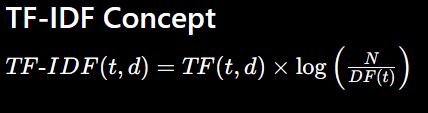

Where:

- \(TF(t,d)\) = Term Frequency of term \(t\) in document \(d\)
- \(DF(t)\) = Document Frequency of term \(t\)
- \(N\) = Total number of documents
- \(TF\text{-}IDF(t,d)\) = Importance score of a term in a document

#### Initialize TF-IDF Vectorizer

In [144]:
word_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words=None,
    ngram_range=(1,3),
    max_features=10000,
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='word'
)

#### Fit & Transform Training Data

In [145]:
X_train_word = word_vectorizer.fit_transform(X_train)

#### Transform Test Data

In [146]:
X_test_word = word_vectorizer.transform(X_test)

#### Check Shapes

In [147]:
print("X_train_word shape:", X_train_word.shape)
print("X_test_word shape:", X_test_word.shape)

X_train_word shape: (22344, 10000)
X_test_word shape: (5586, 10000)


In [148]:
print(X_train.iloc[0])
print(y_train.iloc[0])

tell me about what is rtgs
3


#### View Vocabulary Size

In [149]:
print("Vocabulary Size:", len(tfidf_vectorizer.vocabulary_))

Vocabulary Size: 2715


#### Sample Features

In [150]:
feature_names = word_vectorizer.get_feature_names_out()

feature_names[:20]

array(['123pay', '123pay for', '123pay for banking', '15g', '15g in',
       '15h', '15h in', '1991', '1991 reforms', '1991 reforms in', '24x7',
       '24x7 helpline', '24x7 helpline in', '2fa', '3d', '3d secure',
       '3d secure for', '50', '50 in', 'aaa'], dtype=object)

### Character-Level TF-IDF Features

This helps recognize banking abbreviations and short financial tokens.

Examples:

UPI
NEFT
SWIFT
RTGS
SIP
EMI

#### Initialize Character Vectorizer

In [151]:
char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3,5),
    max_features=5000
)

#### Fit Character Features

In [152]:
X_train_char = char_vectorizer.fit_transform(X_train)

X_test_char = char_vectorizer.transform(X_test)

#### Check Shapes

In [153]:
print("X_train_char shape:", X_train_char.shape)
print("X_test_char shape:", X_test_char.shape)

X_train_char shape: (22344, 5000)
X_test_char shape: (5586, 5000)


### Combine Features

Now combine:

word-level features
character-level features

This significantly improves text classification.

#### Combine Sparse Matrices

In [154]:
X_train_combined = hstack([
    X_train_word,
    X_train_char
])

X_test_combined = hstack([
    X_test_word,
    X_test_char
])

#### Check Combined Shapes

In [155]:
print("X_train_combined shape:", X_train_combined.shape)
print("X_test_combined shape:", X_test_combined.shape)

X_train_combined shape: (22344, 15000)
X_test_combined shape: (5586, 15000)


### Save Preprocessing Artifacts

These will be reused in later notebooks and chatbot deployment.

#### Save Word Vectorizer

In [156]:
with open("../models/word_vectorizer.pkl", "wb") as f:
    pickle.dump(word_vectorizer, f)

print("Word vectorizer saved successfully!")

Word vectorizer saved successfully!


#### Save Character Vectorizer

In [157]:
with open("../models/char_vectorizer.pkl", "wb") as f:
    pickle.dump(char_vectorizer, f)

print("Character vectorizer saved successfully!")

Character vectorizer saved successfully!


#### Save Combined Features

In [158]:
with open("../models/X_train_combined.pkl", "wb") as f:
    pickle.dump(X_train_combined, f)

with open("../models/X_test_combined.pkl", "wb") as f:
    pickle.dump(X_test_combined, f)

print("Combined feature matrices saved successfully!")

Combined feature matrices saved successfully!


#### Save Processed Dataset

In [159]:
df.to_csv(
    "../data/banking_processed.csv",
    index=False
)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


# Key Insights

## 1. Dataset Quality Analysis

### Missing Values
The dataset is highly clean and well-structured.

| Column | Missing Values |
|---|---|
| Section | 0 |
| Question | 0 |
| Answer | 0 |
| question_length | 0 |
| answer_length | 0 |
| clean_question | 5 |

### Observations
- No missing values exist in the core columns:
  - `Section`
  - `Question`
  - `Answer`

- Only 5 missing values were found in `clean_question`, which is negligible and does not significantly impact model training.

- The dataset is suitable for:
  - NLP preprocessing
  - Intent classification
  - Semantic search
  - RAG pipelines

---

## 2. Banking Intent Distribution

The dataset contains 10 balanced banking intent categories.

| Section | Count |
|---|---|
| Basic Accounts | 121 |
| Digital Banking | 116 |
| Loans & Interest | 110 |
| Operations & Security | 109 |
| General Finance | 106 |
| Financial Markets | 92 |
| Customer Service | 91 |
| Insurance & Govt Schemes | 90 |
| Banking Terminology | 86 |
| International Banking | 79 |

### Observations
- The dataset is relatively balanced across categories.
- No severe class imbalance exists.
- Categories such as:
  - Digital Banking
  - Loans & Interest
  - Operations & Security
  
  have strong representation, which improves model learning.

- `International Banking` has the fewest samples but still contains enough examples for training.

### NLP Importance
Balanced categories help improve:
- classification stability
- generalization
- intent prediction consistency

---

## 3. Text Preprocessing Analysis

### Original vs Cleaned Questions

| Original Question | clean_question |
|---|---|
| What is a Savings Account? | saving account |
| What is a Current Account? | current account |
| What is a Fixed Deposit? | fix deposit |
| What does KYC stand for? | kyc stand |
| What is a cheque? | cheque |

### Original vs Processed Questions

| Original Question | processed_question |
|---|---|
| What is a Savings Account? | what is a savings account |
| What is a Current Account? | what is a current account |
| What is a Fixed Deposit? | what is a fixed deposit |
| What does KYC stand for? | what does kyc stand for |
| What is a cheque? | what is a cheque |

### Important Observation
The updated preprocessing strategy preserves:
- conversational structure
- intent-related words
- banking context

instead of aggressively removing information.

This is important because banking queries rely heavily on:
- question structure
- action words
- financial terminology

Examples:
- how to block debit card
- what is emi
- how does upi work

---

## 4. Label Encoding Analysis

The 10 banking categories were successfully converted into numerical labels.

### Label Mapping

| Category | Label |
|---|---|
| Banking Terminology | 0 |
| Basic Accounts | 1 |
| Customer Service | 2 |
| Digital Banking | 3 |
| Financial Markets | 4 |
| General Finance | 5 |
| Insurance & Govt Schemes | 6 |
| International Banking | 7 |
| Loans & Interest | 8 |
| Operations & Security | 9 |

### Observations
- Label encoding prepares the dataset for machine learning models.
- Numerical labels allow efficient multi-class classification.

---

## 5. Train-Test Split Analysis

### Dataset Split

| Dataset | Shape |
|---|---|
| X_train | (800,) |
| X_test | (200,) |
| y_train | (800,) |
| y_test | (200,) |

### Observations
- An 80:20 split was used.
- Stratified sampling preserved category balance across training and testing datasets.
- The split is appropriate for small NLP datasets.

---

## 6. Word-Level TF-IDF Feature Engineering

### Feature Matrix Shapes

| Feature Matrix | Shape |
|---|---|
| X_train_word | (800, 4719) |
| X_test_word | (200, 4719) |

### Vocabulary Size

```python
2715
```

### Sample Vocabulary Terms

```python
['15g', '15h', '1991', '1991 reforms', '1991 reforms in',
 '24x7', '24x7 helpline', '3d', '3d secure',
 '3d secure for', '50', 'aadhaar',
 'aadhaar through', 'aadhaar through the',
 'aadhaar to', 'aadhaar to my',
 'abroad', 'abroad education',
 'abroad education loan', 'access']
```

### Observations
The TF-IDF vectorizer successfully captured:
- banking terminology
- financial phrases
- RBI-related concepts
- digital banking keywords
- government schemes
- financial abbreviations

Examples:
- Aadhaar
- 3D Secure
- 24x7 Helpline
- Education Loan
- 1991 Reforms

### Importance
Word n-grams help capture:
- semantic meaning
- banking entities
- customer intent phrases

---

## 7. Character-Level TF-IDF Features

### Feature Matrix Shapes

| Feature Matrix | Shape |
|---|---|
| X_train_char | (800, 5000) |
| X_test_char | (200, 5000) |

### Observations
Character-level TF-IDF improves recognition of:
- acronyms
- abbreviations
- banking codes
- short financial entities

Examples:
- UPI
- RTGS
- NEFT
- SWIFT
- SIP
- EMI
- NPA

### Importance
Character n-grams are highly effective in banking NLP because many financial terms are short abbreviations.

---

## 8. Combined Sparse Features

### Combined Feature Shapes

| Combined Matrix | Shape |
|---|---|
| X_train_combined | (800, 9719) |
| X_test_combined | (200, 9719) |

### Observations
The final feature representation combines:
- semantic phrase understanding
- character pattern recognition

This creates a richer representation of banking queries.

### Why Combined Features Matter
- Word-level TF-IDF captures meaning.
- Character-level TF-IDF captures financial abbreviations and spelling patterns.
- Combined sparse matrices improve classification robustness.

---

# Final Conclusion

The preprocessing pipeline successfully transformed the banking FAQ dataset into a machine-learning-ready NLP dataset.

The final pipeline includes:
- lightweight text cleaning
- label encoding
- word-level TF-IDF
- character-level TF-IDF
- sparse feature engineering

The dataset is now optimized for:
- Intent Classification
- Semantic Search
- FAISS Retrieval
- RAG Pipelines
- Banking Chatbots
- Generative AI Applications